# 06 — Real Leveraged-ETF Reality Check

Our backtest assumes we can earn exactly `L × (daily S&P return)` forever. Real leveraged ETFs only *approximately* do that — they charge ~0.9% fees, pay financing on borrowed money, and have tracking error. Here we compare:

- **Synthetic** leverage (S&P daily return × L), and
- **Real** ETFs: **SSO** (2x), **UPRO** (3x), **SPXL** (3x).

Does synthetic leverage over- or under-state what an investor could really have captured?

In [1]:
# --- standard setup (run me first) ---
import sys, os
# Make the project root importable so `from src import ...` works from notebooks/.
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Setup complete. Project root:", os.path.abspath(".."))

Setup complete. Project root: C:\Users\Taffy Jackson\leveraged-trend-following


In [2]:
from src import data_loader as dl, data_cleaning as dc, returns as rt
from src import etf_tests as et, plots as pl, config

underlying, ticker, _ = dl.get_underlying_total_return()
u = rt.simple_returns(underlying)
rf = dl.get_risk_free_daily(u.index)
raw = dl.load_universe(['SSO','UPRO','SPXL'])
clean, _ = dc.clean_universe(raw)

## Synthetic vs real, ETF by ETF

In [3]:
rows = []
for t in ['SSO','UPRO','SPXL']:
    if t not in clean: continue
    L = config.TICKERS[t]['leverage']; exp = config.TICKERS[t]['expense']
    etf_r = rt.simple_returns(clean[t])
    cmp = et.compare_synthetic_vs_real(u, etf_r, L, rf_daily=rf, expense_annual=exp)
    rows.append({'etf':t,'leverage':L,'realized_beta':cmp['realized_beta'],
        'tracking_error_ann':cmp['tracking_error_ann'],
        'etf_cagr':cmp['etf_cagr'],'synthetic_costed_cagr':cmp['synthetic_costed_cagr'],
        'gap_costed_minus_etf':cmp['gap_costed_minus_etf']})
import pandas as pd; pd.DataFrame(rows)

,etf,leverage,realized_beta,tracking_error_ann,etf_cagr,synthetic_costed_cagr,gap_costed_minus_etf
0,SSO,2.0000,1.9483,0.0379,0.1565,0.1600,0.0035
1,UPRO,3.0000,2.9673,0.0314,0.3286,0.3345,0.0058
2,SPXL,3.0000,2.9285,0.0456,0.2843,0.2907,0.0064


**Realized beta** should be close to the ETF's target multiple (≈2 for SSO, ≈3 for UPRO/SPXL) — confirming they really do track the daily multiple. The **gap** column shows how much our costed-synthetic CAGR differs from the real ETF: a small positive number means synthetic leverage slightly *overstates* reality (the ETFs lag by a bit due to fees and tracking error).

## Picture: synthetic 2x vs the real SSO

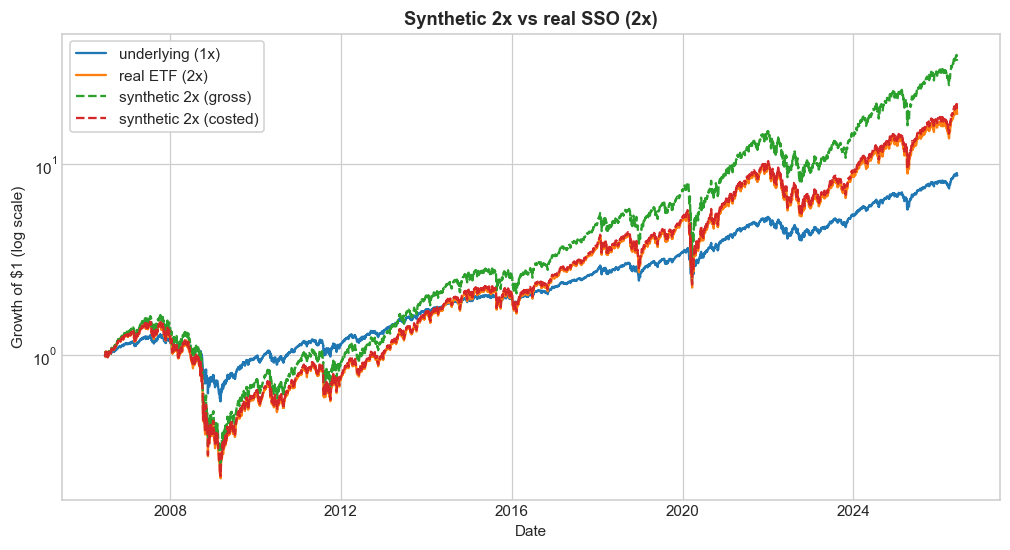

In [4]:
L = 2.0; etf_r = rt.simple_returns(clean['SSO'])
cmp = et.compare_synthetic_vs_real(u, etf_r, L, rf_daily=rf,
    expense_annual=config.TICKERS['SSO']['expense'])
fig = pl.plot_synthetic_vs_real(cmp['curves'],
    'Synthetic 2x vs real SSO (2x)', '06_etf_synth_vs_real_SSO.png')
plt.show()

The costed-synthetic line tracks the real ETF closely; the gross (no-cost) synthetic line runs a bit higher — that gap is roughly the fee + financing drag you actually pay. **Takeaway:** the synthetic backtest is realistic enough to trust its *conclusions*, and if anything it is a touch optimistic, so it cannot be hiding a worse real-world result.

➡️ **Next:** notebook 07 explains *why* leverage behaved the way it did, using Monte Carlo and the arithmetic of volatility decay.